In [ ]:
!pip install qiskit qiskit_aer qiskit-nature scipy pylatexenc qiskit-ibm-runtime pyscf qiskit-nature[pyscf] qiskit-algorithms

In [ ]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp,Operator
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper,ParityMapper,TaperedQubitMapper
from qiskit_algorithms.optimizers import SPSA,COBYLA,L_BFGS_B,SLSQP
from qiskit_nature.second_q.circuit.library import UCCSD,HartreeFock,UCC
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel,depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeManilaV2,FakeCairoV2
from qiskit.primitives import BackendEstimatorV2
from qiskit import transpile
from qiskit.quantum_info import Statevector

In [ ]:
from scipy.linalg import dft

In [ ]:
estimator=Estimator()

In [ ]:
import numpy as np
from scipy.linalg import dft
from qiskit.quantum_info import Operator, SparsePauliOp

def hamiltonian(num_qubits, alpha=65.2427):
    N = 2**num_qubits
    diag_elements = []
    n = -N/2
    for _ in range(N):
        diag_elements.append(n)
        n += 1
    matrix = np.sqrt(np.pi/2*N)*np.diag(diag_elements)

    F_d = dft(N, scale='sqrtn')
    F_d_inv = np.conjugate(F_d).T
    p_d = F_d_inv @ matrix @ F_d
    pd_sq = p_d @ p_d
    hamiltonian_matrix = alpha * pd_sq

    hamiltonian_op = Operator(hamiltonian_matrix)

    raw_pauli = SparsePauliOp.from_operator(hamiltonian_op)

    clean_coeffs = np.real(raw_pauli.coeffs)
    qubit_op = SparsePauliOp(raw_pauli.paulis, coeffs=clean_coeffs)

    simplified_qubit_op = qubit_op.simplify(atol=1e-6)

    return np.real(hamiltonian_matrix), simplified_qubit_op

In [ ]:
hamiltonian,qubit_hamiltonian=hamiltonian(2)

In [ ]:
print(qubit_hamiltonian)

SparsePauliOp(['II', 'IX', 'XI', 'XX'],
              coeffs=[614.89796106+0.j, 409.93197404+0.j, 204.96598702+0.j, 409.93197404+0.j])


In [ ]:
values=[]
counts=[]
def callback(eval_count, parameters, mean, std):
    values.append(mean)
    counts.append(eval_count)

ansatz = TwoLocal(
    num_qubits=2,
    rotation_blocks=['ry'],
    entanglement_blocks='cx',
    entanglement='linear',
    reps=1
)


vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=1000),
    initial_point=np.zeros(ansatz.num_parameters),
    callback=callback
)

/tmp/ipykernel_2476/1920843917.py:7: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


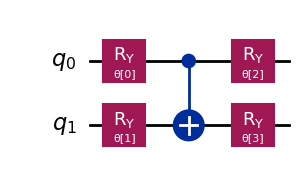

In [ ]:
ansatz.decompose().draw('mpl')

In [ ]:
vqe_energy=vqe.compute_minimum_eigenvalue(qubit_hamiltonian).eigenvalue.real
print(f"VQE Energy: {vqe_energy}")

VQE Energy: 4.263256414560601e-13


In [ ]:
exact_energy=np.linalg.eigvalsh(hamiltonian)[0]
print(f"Exact Energy: {exact_energy}")

Exact Energy: 2.1712257789870957e-13


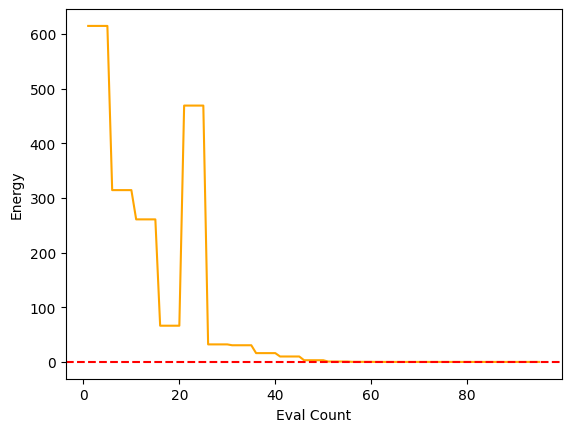

In [ ]:
plt.plot(counts,values,color='orange',linestyle='-')
plt.axhline(exact_energy,color='red',linestyle='--')
plt.xlabel("Eval Count")
plt.ylabel("Energy")
plt.show()